In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/datasets/faizanhaider01/attendance/student_scores.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/attendance/student_scores.csv')

In [4]:
df.sample(4)

,study_hours,attendance_pct,exam_score
11,9.7,58.1,75.5
81,6.6,55.7,61.9
67,8.2,59.3,75.4
93,6.1,81.7,69.4


In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [7]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

In [9]:
#RESIDUAL:
residual = y_test - y_pred

# 1.Linear Realtionship

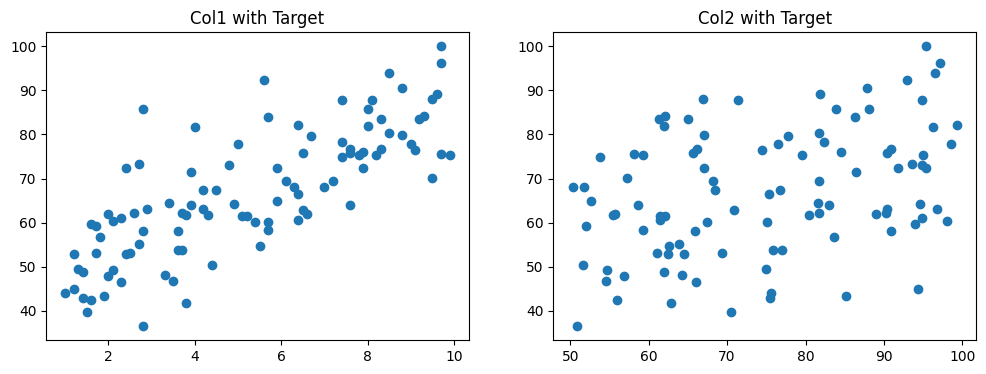

In [13]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,4))
ax1.scatter(x=df['study_hours'],y=df['exam_score'])
ax1.set_title('Col1 with Target')
ax2.scatter(x=df['attendance_pct'],y=df['exam_score'])
ax2.set_title('Col2 with Target')
plt.show()


# 2. Multicollinearity

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [15]:
pd.DataFrame({'vif': vif}, index=df.columns[0:2]).T

,study_hours,attendance_pct
vif,3.91519,3.91519


<Axes: >

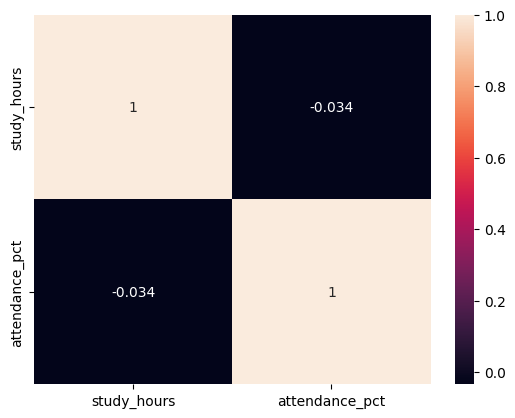

In [16]:
# Another Technique
sns.heatmap(df.iloc[:,0:2].corr(),annot=True)

# 3. Normality of Residual

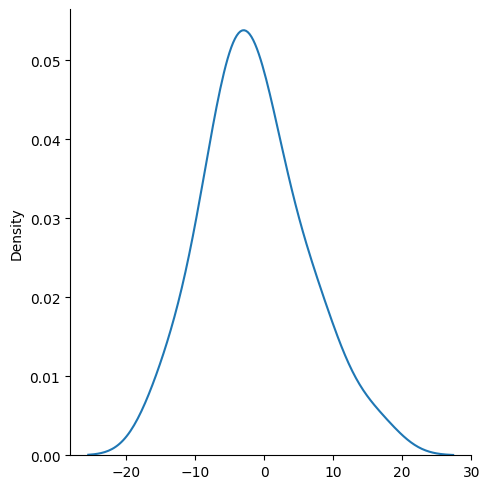

In [17]:
sns.displot(residual,kind='kde')

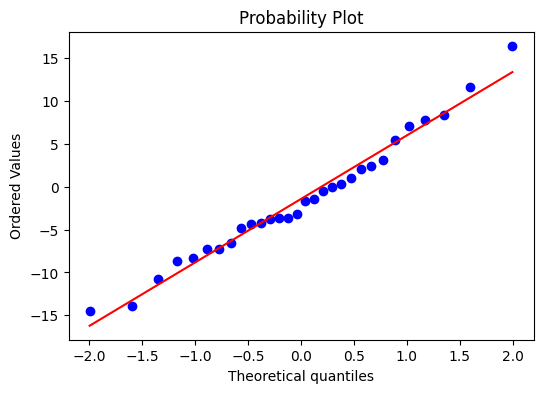

In [18]:
# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

# 4. Homoscedasticity

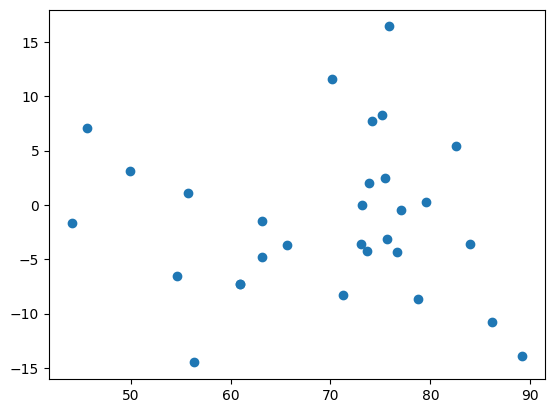

In [19]:
plt.scatter(y_pred,residual)

# 5. Autocorrelation of Residuals

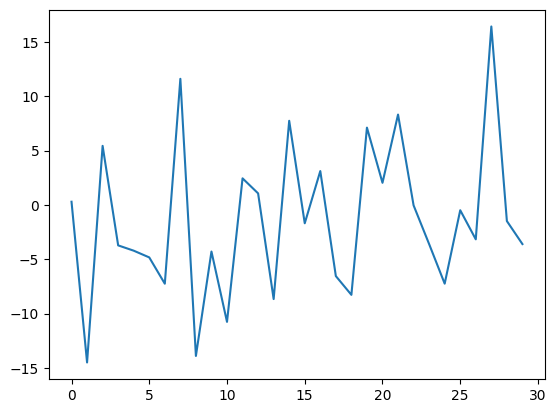

In [20]:

plt.plot(residual)